In [10]:
# help from https://github.com/michaeldavie/env_canada/blob/main/README.md
# and https://pypi.org/project/env_canada/

import asyncio
import pandas as pd

from env_canada import ECWeather
from env_canada import ECHistorical
from env_canada.ec_historical import get_historical_stations




In [29]:
# Using coordinates (automatic station selection)

# Vancouver coords
ec_coords = ECWeather(coordinates=(49.246, -123.116), )

# Esquimalt station
ec_station = ECWeather(station_id="BC/s0000286") 

await (ec_coords.update())
await (ec_station.update())

# current conditions
#ec_coords.conditions
#ec_coords.daily_forecasts

#print(ec_coords.conditions)
ec_station.conditions

{'temperature': {'label': 'Temperature', 'unit': 'C', 'value': 15.3},
 'dewpoint': {'label': 'Dew Point', 'unit': 'C', 'value': 8.3},
 'wind_chill': {'label': 'Wind Chill', 'value': None},
 'humidex': {'label': 'Humidex', 'value': None},
 'pressure': {'label': 'Pressure', 'unit': 'kPa', 'value': 102.0},
 'tendency': {'label': 'Tendency', 'unit': 'kPa', 'value': 'falling'},
 'humidity': {'label': 'Humidity', 'unit': '%', 'value': 63},
 'visibility': {'label': 'Visibility', 'value': None},
 'condition': {'label': 'Condition', 'value': None},
 'wind_speed': {'label': 'Wind Speed', 'unit': 'km/h', 'value': 9},
 'wind_gust': {'label': 'Wind Gust', 'value': None},
 'wind_dir': {'label': 'Wind Direction', 'value': 'NE'},
 'wind_bearing': {'label': 'Wind Bearing', 'unit': 'degrees', 'value': 50},
 'high_temp': {'label': 'High Temperature', 'unit': 'C', 'value': 16},
 'low_temp': {'label': 'Low Temperature', 'unit': 'C', 'value': 10},
 'uv_index': {'label': 'UV Index', 'value': 4},
 'pop': {'la

In [17]:
# get stations to get historical data
input_lat = 49.246
input_lon = -123.116
coordinates = [input_lat, input_lon]  # [lat, long]

# coordinates: [lat, long]
# radius: km
# limit: response limit, value one of [10, 25, 50, 100]
# The result contains station names and ID values.
stations = await (get_historical_stations(coordinates, radius=50, limit=50))
#stations
# 'VANCOUVER INTL A': {'prov': 'BC',
#   'proximity': 7.54,
#   'id': '1108395',
#   'hlyRange': '2013-06-11|2026-09-29',
#   'dlyRange': '2013-06-13|2026-09-29',
#   'mlyRange': '|'}

In [19]:
ec_en_csv = ECHistorical(
    station_id=1108395, 
    year=2026, 
    #month=1, 
    language="english", format="csv", 
    #timeframe=1
)

await (ec_en_csv.update())

df = pd.read_csv(ec_en_csv.station_data)
df.head(10)

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-01,2026,1,1,NaN,5.4,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
1,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-02,2026,1,2,NaN,9.1,...,0.0,NaN,3.0,NaN,NaN,NaN,NaN,M,NaN,M
2,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-03,2026,1,3,NaN,10.4,...,0.0,NaN,18.6,NaN,NaN,NaN,10.0,NaN,32.0,NaN
3,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-04,2026,1,4,NaN,9.8,...,0.0,NaN,3.4,NaN,NaN,NaN,19.0,NaN,58.0,NaN
4,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-05,2026,1,5,NaN,6.9,...,0.0,NaN,0.0,T,NaN,NaN,30.0,NaN,46.0,NaN
5,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-06,2026,1,6,NaN,7.2,...,0.0,NaN,8.1,NaN,NaN,NaN,16.0,NaN,46.0,NaN
6,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-07,2026,1,7,NaN,6.0,...,0.0,NaN,10.1,NaN,NaN,NaN,27.0,NaN,45.0,NaN
7,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-08,2026,1,8,NaN,7.6,...,0.0,NaN,0.3,NaN,NaN,NaN,27.0,NaN,48.0,NaN
8,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-09,2026,1,9,NaN,8.5,...,0.0,NaN,1.7,NaN,NaN,NaN,11.0,NaN,39.0,NaN
9,-123.18,49.19,VANCOUVER INTL A,1108395,2026-01-10,2026,1,10,NaN,8.4,...,0.0,NaN,6.2,NaN,NaN,NaN,7.0,NaN,37.0,NaN


In [22]:
df.columns

Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)',
       'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)',
       'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag',
       'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)',
       'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag',
       'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)',
       'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)',
       'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)',
       'Spd of Max Gust Flag'],
      dtype='str')

Matplotlib is building the font cache; this may take a moment.
/opt/anaconda3/envs/weather2_0/lib/python3.14/inspect.py:2686: RuntimeWarning: coroutine 'ECWeather.update' was never awaited
  def __init__(self, name, kind, *, default=_empty, annotation=_empty):
/opt/anaconda3/envs/weather2_0/lib/python3.14/inspect.py:2686: RuntimeWarning: coroutine 'get_historical_stations' was never awaited
  def __init__(self, name, kind, *, default=_empty, annotation=_empty):


<Axes: >

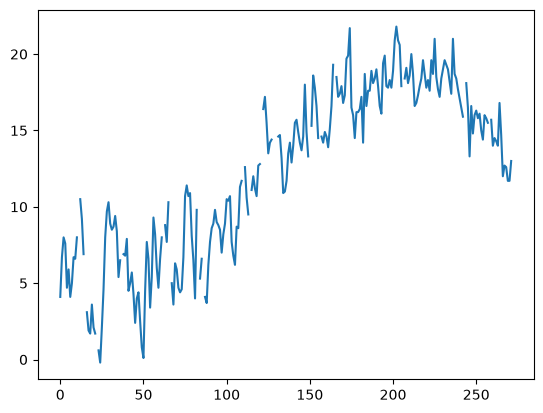

In [23]:
df['Mean Temp (°C)'].plot()